Using Colab cache for faster access to the 'test-file' dataset.
['tested.csv']
Accuracy: 0.4444444444444444

Classification Report:
               precision    recall  f1-score   support

       False       0.40      0.86      0.55         7
        True       0.67      0.18      0.29        11

    accuracy                           0.44        18
   macro avg       0.53      0.52      0.42        18
weighted avg       0.56      0.44      0.39        18


Confusion Matrix:
 [[6 1]
 [9 2]]


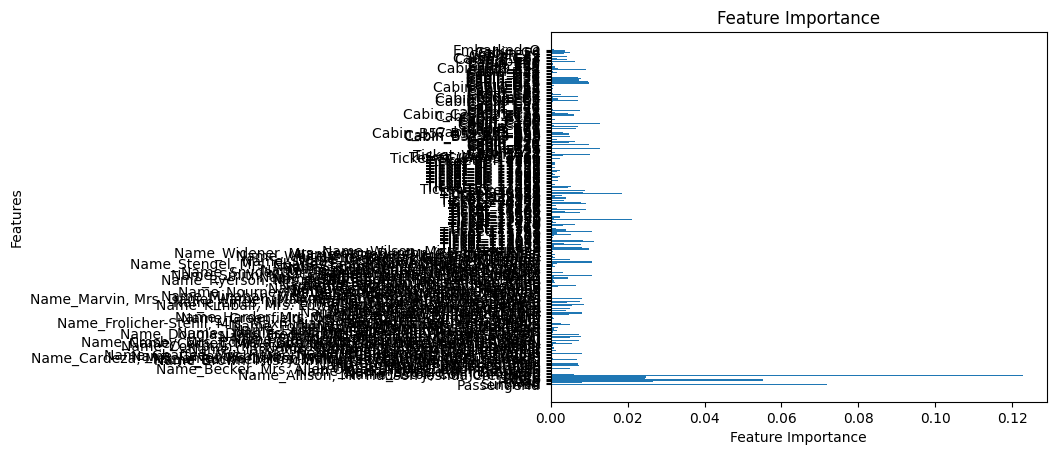

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
import kagglehub
path = kagglehub.dataset_download("brendan45774/test-file")

# Check files inside the downloaded folder
print(os.listdir(path))

# Replace 'your_file.csv' with actual file name shown above
file_path = os.path.join(path, os.listdir(path)[0])

df = pd.read_csv(file_path)

# Basic preprocessing
df = df.dropna()
df = pd.get_dummies(df, drop_first=True)

# Feature selection
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model training
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Feature importance
importance = model.feature_importances_
feature_names = X.columns

plt.barh(feature_names, importance)
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance")
plt.show()